<a href="https://colab.research.google.com/github/tayaland1514/statprak_hw/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Описание датасета

https://www.kaggle.com/c/GiveMeSomeCredit/data

Датасет содержит информацию о заёмщиках и их кредитной истории.  
Для каждого заёмщика представлены различные характеристики: возраст, уровень долговой нагрузки, количество кредитных линий, история просрочек и тп

Целевая переменная `default` показывает, была ли у заёмщика серьёзная просрочка платежа (более 90 дней) в течение двух лет


## Постановка задачи

Целью работы является построение модели машинного обучения, которая по характеристикам заёмщика будет предсказывать вероятность возникновения серьёзной просрочки платежа


##Загрузка данных и EDA

In [ ]:
import pandas as pd

df = pd.read_csv("cs-training.csv")

Переименовываем часть столбцов, чтобы было понятно, что означает каждый из них

In [ ]:
df = df.rename(columns={
    "SeriousDlqin2yrs": "default",
    "RevolvingUtilizationOfUnsecuredLines": "credit_utilization",
    "NumberOfTime30-59DaysPastDueNotWorse": "late_30_59_days",
    "DebtRatio": "debt_ratio",
    "MonthlyIncome": "monthly_income",
    "NumberOfOpenCreditLinesAndLoans": "num_credit_lines",
    "NumberOfTimes90DaysLate": "late_90_days",
    "NumberRealEstateLoansOrLines": "real_estate_loans",
    "NumberOfTime60-89DaysPastDueNotWorse": "late_60_89_days",
    "NumberOfDependents": "dependents"
})

In [ ]:
df.head()

,Unnamed: 0,default,credit_utilization,age,late_30_59_days,debt_ratio,monthly_income,num_credit_lines,late_90_days,real_estate_loans,late_60_89_days,dependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Первый столбец — это целевая переменная `default`

Она показывает, была ли у заёмщика серьёзная просрочка по кредиту:
- 0 — просрочки более чем на 90 дней не было
- 1 — была просрочка более чем на 90 дней

`default` — это переменная, которую в дальнейшем необходимо будет предсказывать, используя признаки заёмщика

Признаки заёмщика (остальные столбцы):

- `credit_utilization` — доля использованного кредитного лимита
- `age` — возраст заёмщика
- `late_30_59_days` — количество просрочек на 30–59 дней
- `late_60_89_days` — количество просрочек на 60–89 дней
- `late_90_days` — количество просрочек более чем на 90 дней
- `debt_ratio` — отношение ежемесячных платежей по долгам к ежемесячному доходу
- `monthly_income` — ежемесячный доход
- `num_credit_lines` — количество открытых кредитных линий
- `real_estate_loans` — количество кредитов на недвижимость
- `dependents` — количество иждивенцев

Далее построим корреляционную матрицу признаков, чтобы:
- выявить сильные зависимости между признаками, которые могут влиять на работу моделей
- проверить, есть ли признаки, сильно коррелирующие с целевой переменной `default`

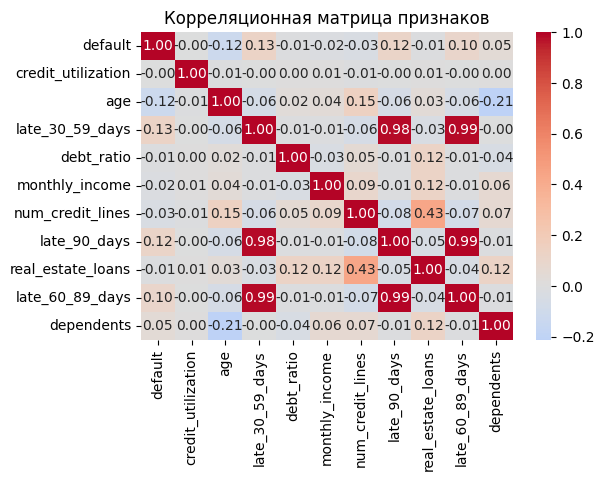

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cols_to_check = [
    'default', 'credit_utilization', 'age',
    'late_30_59_days', 'debt_ratio', 'monthly_income',
    'num_credit_lines', 'late_90_days', 'real_estate_loans',
    'late_60_89_days', 'dependents'
]

plt.figure(figsize=(6, 4))
corr_matrix = df[cols_to_check].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Корреляционная матрица признаков")
plt.show()

- Признаки, связанные с просрочками (`late_30_59_days`, `late_60_89_days`, `late_90_days`), имеют очень высокую корреляцию между собой, то есть если человек задерживает платежи на 30–59 дней, то он с высокой вероятностью задерживает и на 60–89, и на 90+ дней

- Использование всех трёх признаков одновременно может приводить к дублированию одной и той же информации: модель начинает учитывать один и тот же сигнал несколько раз и не может корректно разделить вклад признаков.
Поэтому мы объединим их в один признак, который будет отражать общее количество просрочек

- Остальные признаки не имеют сильных взаимосвязей, которые могли бы повлиять на работу моделей

- Признаков, сильно коррелирующих с целевой переменной `default`, нет


Далее посмотрим на дисбаланс классов:

In [ ]:
df["default"].value_counts(normalize=True)

,proportion
default,
0,0.93316
1,0.06684


Целевая переменная несбалансированная - будем это учитывать при оценке качества моделей

Далее построим гистограмму всех встречающихся возрастов, чтобы понять, как распределены значения и есть ли какие-то аномалии или выбросы

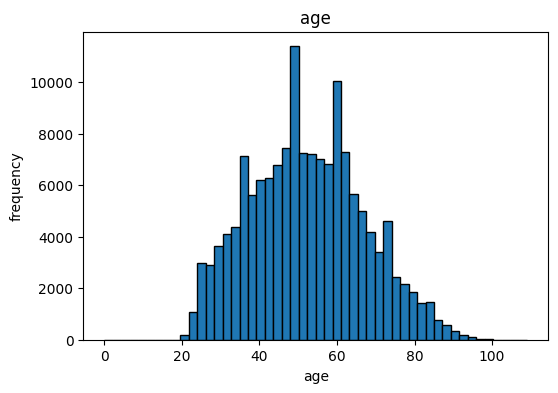

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df["age"].dropna(), bins=50, edgecolor="black")
plt.title("age")
plt.xlabel("age")
plt.ylabel("frequency")
plt.show()

Проверим, есть ли аномальные значения среди возрастов заемщиков:

In [ ]:

df["age"].value_counts().sort_index().tail(10)

,count
age,
96,18
97,17
98,6
99,9
101,3
102,3
103,3
105,1
107,1


In [ ]:
df["age"].value_counts().sort_index().head(10)

,count
age,
0,1
21,183
22,434
23,641
24,816
25,953
26,1193
27,1338
28,1560


Заемщику не может быть 0 лет, и два 109-летних заемщика (а также 101,102,103,105,107-летние заемщики) это тоже странно, так что впоследствие удалим это

Далее строим гистограммы для признаков credit_utilization и monthly_income:

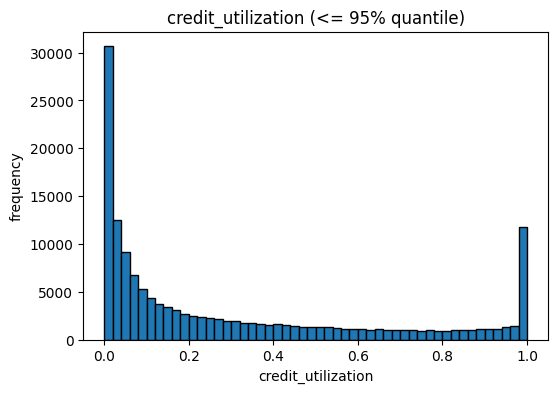

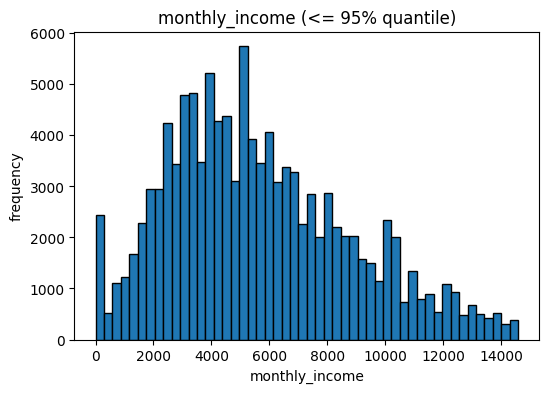

In [ ]:
def plot_trimmed(feature):
    q = df[feature].quantile(0.95)

    plt.figure(figsize=(6, 4))
    plt.hist(df[df[feature] <= q][feature].dropna(), bins=50, edgecolor="black")
    plt.title(f"{feature} (<= 95% quantile)")
    plt.xlabel(feature)
    plt.ylabel("frequency")
    plt.show()

for feature in ["credit_utilization", "monthly_income"]:
    plot_trimmed(feature)


- Признак credit_utilization - это доля использованного кредитного лимита, он показывает, какую часть доступного кредита человек уже использует:

- $\text{credit_utilization} = \frac{\text{текущая задолженность}}{\text{кредитный лимит}}$

- credit_utilization актуальна только для кредитных карт и возобновляемых кредитных линий
	​
- Значения credit_utilization лежат в диапазоне от 0 до 1, где 1 означает, что лимит полностью исчерпан

- Большинство заёмщиков используют небольшую часть доступного кредитного лимита => они несильно зависимы от кредитных средств

- Признак monthly_income - это ежемесячный доход заёмщика

- Распределение monthly_income скошено вправо: большинство заёмщиков имеют относительно невысокий доход, при этом присутствует небольшое число заёмщиков с очень высоким доходом

Для этих признаков распределение сильно искажается из-за редких, но очень больших значений, поэтому ограничиваем значения сверху 95%-квантилем

Далее проверим максимальное значение признака credit_utilization:

In [ ]:
df["credit_utilization"].max()

50708.0

- Получается, в столбце credit_utilization есть аномальные значения (максимальное среди них — 50708, что сильно больше единицы), которые, вероятно, возникают из-за деления на очень маленькое значение кредитного лимита или ошибок в данных, и не имеют экономического смысла

- Для корректной работы модели все значения этого признака > 1 заменим на единицу, тк они либо отражают перегруз по кредиту, либо являются особенностями данных, при этом точное значение уже не даёт дополнительной информации


Далее строим гистограмму для признака debt_ratio:



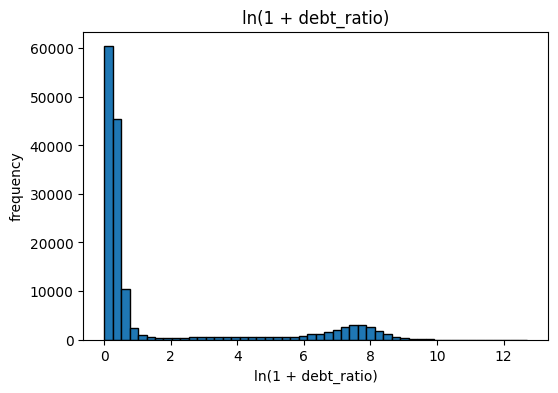

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(np.log1p(df["debt_ratio"].dropna()), bins=50, edgecolor="black")
plt.title("ln(1 + debt_ratio)")
plt.xlabel("ln(1 + debt_ratio)")
plt.ylabel("frequency")
plt.show()

- $debt\_ratio = \frac{\text{ежемесячные платежи по долгам}}{\text{ежемесячный доход}}$

- debt_ratio имеет смысл для всех видов кредитов

- debt_ratio тоже имеет сильную асимметрию и выбросы. При этом если попытаться также ограничить значения 95%-квантилем, распределение всё равно остаётся сильно скошенным, тк даже внутри этого диапазона большая часть наблюдений находится около нуля, а редкие большие значения продолжают искажать масштаб. Поэтому применяем ln(debt_ratio + 1)

- Большинство значений debt_ratio сосредоточено около нуля, то есть у большинства заёмщиков долговая нагрузка небольшая по сравнению с доходом

Теперь рассмотрим признаки, связанные с просрочками платежей:

- $late\_30\_59\_days$ — число случаев, когда заёмщик задерживал платеж на 30–59 дней
- $late\_60\_89\_days$ — число случаев, когда заёмщик задерживал платеж на 60–89 дней
- $late\_90\_days$ — число случаев, когда заёмщик задерживал платеж более чем на 90 дней


Это дискретные переменные, поэтому вместо гистограмм удобнее посмотреть частоты значений - это поможет понять, какие значения встречаются чаще всего и есть ли аномалии

In [ ]:
for col in ["late_30_59_days", "late_60_89_days", "late_90_days"]:
    print(df[col].value_counts().sort_index().head(20))
    print()

late_30_59_days
0     126018
1      16033
2       4598
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64

late_60_89_days
0     142396
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64

late_90_days
0     141662
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64



Видно, что большинство заёмщиков не допускают просрочек, а их случаи встречаются редко, но являются важным сигналом риска

Теперь рассмотрим признаки, показывающие количество кредитов на недвижимость.
Это также дискретные переменные, поэтому вместо гистограмм рассмотрим частоты значений:

In [ ]:
df["real_estate_loans"].value_counts().sort_index()

,count
real_estate_loans,
0,56188
1,52338
2,31522
3,6300
4,2170
5,689
6,320
7,171
8,93


В признаке real_estate_loans встречаются отдельные большие значения (20 и более кредитов на недвижимость), которые выглядят нереалистично и нетипично для большинства заёмщиков

Такие наблюдения встречаются крайне редко, 1-3 раза каждое, поэтому вряд ли это специальная кодировка (иначе они бы систематически встречались гораздо чаще)

Так что, вероятно, эти наблюдения соответствуют специфическим случаям (возможно, инвестиции в недвижимость) или ошибке данных, но, поскольку их сравнительно мало, дополнительно обрабатывать их не будем

##Выводы по EDA:

- В непрерывных признаках (age, credit_utilization, debt_ratio, monthly_income):  

  Признак age имеет распределение, близкое к нормальному, и содержит незначительное количество аномалий

  В признаке credit_utilization есть аномальные значения, сильно превышающие единицу (при том, что credit_utilization может принимать только значения от 0 до 1), и эти значения мы далее заменим на единицу, тк они либо отражают перегруз по кредиту, либо являются особенностями данных, при этом точное значение уже не даёт дополнительной информации

  В признаках credit_utilization и monthly_income присутствуют редкие, но очень большие значения, которые искажают распределение, поэтому для анализа мы берем ограничение по 95%-квантилю  

  Признак debt_ratio имеет сильную асимметрию и длинный правый хвост, из-за чего даже после ограничения квантилем распределение остаётся скошенным — поэтому к нему применили $ln(\text{debt_ratio} + 1)$

- Большинство значений в столбцах значений просрочек платежей по кредитам (late_30_59_days, late_60_89_days и late_90_days) равны 0, то есть большинство заемщиков выплачивают все вовремя

  Но при этом довольно часто встречаются аномальные значения 96 и 98 - они не могут интерпретироваться как реальное количество просрочек, тк это означало бы множественные случаи серьёзных задержек платежей, что экономически маловероятно

  Поэтому мы предполагаем, что это ошибки или кодировка пропусков

  Дальше такие значения будут заменены на NaN

- В признаке real_estate_loans встречаются отдельные большие значения, нетипичные для большинства заёмщиков. Они наблюдаются крайне редко => это не кодировка пропусков, а либо специфические случаи, либо ошибки данных

  Поскольку таких наблюдений мало, дополнительная обработка не нужна


### Предобработка данных

По результатам EDA выполним обработку аномальных значений и пропусков

- Удаляем нереалистичные значения возрастов заемщиков:

In [ ]:
df = df[(df["age"] > 0) & (df["age"] < 100)]

- Для столбцов значений просрочек платежей late_30_59_days, late_60_89_days, late_90_days считаем некорректными значениями 96 и 98;

- Для столбца credit_utilization, показывающего доли использованного кредитного лимита, все значения, большие 1, приводим к 1 (ограничиваем сверху):

In [ ]:
for col in ["late_30_59_days", "late_60_89_days", "late_90_days"]:
    df[col] = df[col].replace([96, 98], np.nan)

df["credit_utilization"] = df["credit_utilization"].clip(upper=1)

Смотрим, где сколько пропусков после того, как заменили аномальные значения на NaN:

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
default,0
credit_utilization,0
age,0
late_30_59_days,269
debt_ratio,0
monthly_income,29724
num_credit_lines,0
late_90_days,269
real_estate_loans,0


- Пропуски в столбце с ежемесячным доходом заполняем медианой, тк она устойчива к выбросам;

- Пропуски в столбце с количеством иждивенцев тоже заполняем медианой;

- Пропуски в столбце с количеством просрочек платежей заполняем нулями:

In [ ]:
df["monthly_income"] = df["monthly_income"].fillna(df["monthly_income"].median())
df["dependents"] = df["dependents"].fillna(df["dependents"].median())

for col in ["late_30_59_days", "late_60_89_days", "late_90_days"]:
    df[col] = df[col].fillna(0)

Проверяем, что пропусков больше нет:

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
default,0
credit_utilization,0
age,0
late_30_59_days,0
debt_ratio,0
monthly_income,0
num_credit_lines,0
late_90_days,0
real_estate_loans,0


- Объединяем признаки late_30_59_days, late_60_89_days и late_90_days в один признак:

In [ ]:
df["total_late"] = (
    df["late_30_59_days"] +
    df["late_60_89_days"] +
    df["late_90_days"]
)

df = df.drop(columns=[
    "late_30_59_days",
    "late_60_89_days",
    "late_90_days"
])

- Удаляем столбец с индексами, он не нужен:

In [ ]:
df = df.drop(columns=["Unnamed: 0"])

- Для признака debt_ratio применяем логарифмическое преобразование, тк он имеет сильную асимметрию:

In [ ]:
df["debt_ratio"] = np.log1p(df["debt_ratio"])

### Постановка задачи

Цель — построить модель, которая по характеристикам заёмщика будет предсказывать вероятность серьёзной просрочки платежа

Формально требуется оценить условную вероятность

$$
P(\text{default} = 1 \mid X),
$$

где $X$ — вектор признаков заёмщика

Переменная default принимает два значения:
- 0 — отсутствует серьёзная просрочка
- 1 — имеется просрочка более чем на 90 дней

То есть задача сводится к бинарной классификации: нужно по признакам заёмщика определить, будет ли он относиться к классу с дефолтом или без, то есть допустит ли он просрочку более чем на 90 дней в ближайшие два года

### Выбор моделей и метрик

Для решения задачи бинарной классификации будем использовать следующие модели:
- логистическую регрессию
- kNN

Логистическая регрессия выбрана как базовая модель, тк она позволяет напрямую оценивать вероятность дефолта и хорошо интерпретируется: можно понять, как признаки влияют на риск

Метод kNN рассматривается как более гибкий алгоритм, который не делает предположений о виде зависимости и может учитывать локальную структуру данных. Но он хуже работает, когда один класс встречается намного чаще другого (как в нашем случае, где дефолтов около 7%, а не дефолтов где-то 93%). Поэтому основным алгоритмом будет логистическая регрессия

Для оценки качества моделей будем использовать следующие метрики:
- accuracy
- ROC-AUC
- precision
- recall
- F1-score

Метрика accuracy показывает долю правильно классифицированных наблюдений. Но целевая переменная является несбалансированной: доля дефолтов значительно меньше доли недефолтов. В таких условиях accuracy может давать завышенную оценку качества модели, так как модель может достигать высокой точности, просто предсказывая наиболее частый класс

Поэтому для оценки качества используется метрика ROC-AUC, и ориентироваться, в основном, будем на нее

ROC-AUC позволяет оценивать, насколько хорошо модель расставляет заёмщиков по уровню риска — от более надёжных к более рискованным, и не зависит от выбранного порога классификации

Precision показывает, какая доля предсказанных дефолтов действительно является дефолтами

Recall показывает, какую долю реальных дефолтов модель смогла обнаружить

F1-score является гармоническим средним precision и recall и позволяет учитывать баланс между этими метриками




## Подготовка данных для обучения моделей



Выделим целевую переменную и признаки:


In [ ]:
X = df.drop(columns=["default"])
y = df["default"]

Разделим данные на обучающую и тестовую части, используем `stratify=y`, чтобы сохранялось соотношение классов в обеих выборках:

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Приведём признаки к одному масштабу

Это важно для kNN, так как метод основан на расстояниях между объектами  
Для логистической регрессии масштабирование делает обучение более устойчивым

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Обучим базовую логистическую регрессию, и затем подберём гиперпараметры

Так как классы несбалансированы, дополнительно попробуем учитывать этот дисбаланс через параметр `class_weight`

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)
y_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Precision:", precision_score(y_test, y_pred_logreg))
print("Recall:", recall_score(y_test, y_pred_logreg))
print("F1-score:", f1_score(y_test, y_pred_logreg))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_logreg))

Accuracy: 0.9365291019401294
Precision: 0.5940409683426443
Recall: 0.15910224438902743
F1-score: 0.25098347757671124
ROC-AUC: 0.8564966856249152


Выводы по метрикам логистической регрессии:

- Ниже будем использовать следующие обозначения:
  - **TP (True Positive)** — правильно предсказанные дефолты
  - **FP (False Positive)** — неверно предсказанные дефолты (модель предсказала дефолт, но на самом деле не дефолт)
  - **TN (True Negative)** — правильно предсказанные недефолты
  - **FN (False Negative)** — неверно предсказанные недефолты (модель пропустила дефолт)

- **Accuracy** (=0.93) самая высокая, но в условиях сильного дисбаланса классов (примерно 93% и 7%) она гарантированно ни о чем не говорит, так как модель может просто всегда угадывать наиболее часто встречающийся класс (0, не дефолт) и получать высокий процент правильных предсказаний  

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

- **Precision** (=0.59) показывает долю верно предсказанных дефолтов среди всех предсказанных дефолтов, делает это достаточно точно
  
  Более критичной является ошибка пропуска дефолта (FN), поэтому допустимо некоторое увеличение ложных срабатываний (FP), если это позволяет выявить больше реальных дефолтов

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

- **Recall** (=0.16) показывает долю верно предсказанных дефолтов среди всех реальных дефолтов  

  Чем выше Recall, тем меньше реальных дефолтов мы пропускаем

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

- **F1-score** (=0.25) объединяет Precision и Recall

$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

- **ROC-AUC** (=0.856, вторая по величине после accuracy) демонстрирует способность модели ранжировать заемщиков по уровню риска дефолта и не зависит от порога классификации  

$$
\text{ROC-AUC} = \int_0^1 TPR(FPR)\, dFPR, \quad
TPR = \frac{TP}{TP + FN}, \quad
FPR = \frac{FP}{FP + TN}
$$

**Вывод:**

- Модель хорошо ранжирует заемщиков по риску (высокий ROC-AUC)  
- Но при стандартном пороге классификации почти не находит дефолты (низкий Recall)  
- Это означает, что проблема не столько в самой модели, сколько в выборе порога  
- В задаче кредитного скоринга более критично не пропускать дефолты, чем избегать ложных срабатываний  

Поэтому:
- необходимо ориентироваться на ROC-AUC
- и в дальнейшем можно сдвигать порог, чтобы увеличить Recall  

**Вывод:** логистическая регрессия подходит для задачи, так как хорошо ранжирует риск, но требует дополнительной настройки порога классификации

Подберём гиперпараметры для логистической регрессии с помощью `GridSearchCV`

Будем варьировать:
- `C` — параметр регуляризации
- `penalty` — тип регуляризации
- `class_weight` — способ учёта дисбаланса классов

В качестве основной метрики при подборе используем `roc_auc`

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_logreg = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "class_weight": [None, "balanced"],
    "solver": ["lbfgs"]
}

grid_logreg = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid_logreg,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_logreg.fit(X_train_scaled, y_train)

print("Лучшие параметры:", grid_logreg.best_params_)
print("Лучшая ROC-AUC на кросс-валидации:", grid_logreg.best_score_)

Лучшие параметры: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Лучшая ROC-AUC на кросс-валидации: 0.8499702688056917


Вывод после подбора гиперпараметров логистической регрессии:

- Лучшая ROC-AUC на кросс-валидации: 0.85
  
- Это означает, что модель хорошо ранжирует заемщиков по вероятности дефолта, даже если точные предсказания классов (0/1) иногда ошибочны

После подбора гиперпараметров выбираем лучшую модель логистической регрессии и оцениваем её качество на тестовой выборке

Для этого:
- получим предсказания классов (0 или 1)
- получим вероятности дефолта
- рассчитаем метрики качества: accuracy, precision, recall, F1-score и ROC-AUC


In [ ]:
best_logreg = grid_logreg.best_estimator_

y_pred_logreg = best_logreg.predict(X_test_scaled)
y_proba_logreg = best_logreg.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Precision:", precision_score(y_test, y_pred_logreg))
print("Recall:", recall_score(y_test, y_pred_logreg))
print("F1-score:", f1_score(y_test, y_pred_logreg))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_logreg))

Accuracy: 0.7941862790852724
Precision: 0.2123637367186422
Recall: 0.7675810473815461
F1-score: 0.3326848249027237
ROC-AUC: 0.8601039109082579


Комментарий по сравнению с моделью до подбора гиперпараметров:

После подбора гиперпараметров Accuracy немного уменьшилась, что типично при учёте дисбаланса классов  

Precision снизилась, Recall увеличился, F1-score немного изменился, а основная метрика ROC-AUC возросла до 0.86, что демонстрирует улучшение способности модели ранжировать заемщиков по риску дефолта

Подберем теперь порог классификации для логистической регрессии

Логистическая регрессия предсказывает вероятность дефолта, а затем относит объект к классу 1, если вероятность выше выбранного порога

По умолчанию используется порог 0.5, но в нашей задаче важнее не пропускать дефолтных заёмщиков, поэтому имеет смысл подобрать порог так, чтобы увеличить Recall

Порог будем подбирать на обучающей выборке с помощью кросс-валидации, а затем проверим результат на тестовой выборке

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

y_train_proba_cv = cross_val_predict(
    best_logreg,
    X_train_scaled,
    y_train,
    cv=5,
    method="predict_proba"
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, y_train_proba_cv)

thresholds_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

In [ ]:
target_recall = 0.75

valid_thresholds = thresholds_df[thresholds_df["recall"] >= target_recall]

best_threshold = valid_thresholds.sort_values(
    by="precision",
    ascending=False
).iloc[0]["threshold"]

best_threshold

np.float64(0.49429277572195374)

In [ ]:
y_pred_logreg_threshold = (y_proba_logreg >= best_threshold).astype(int)

print("Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, y_pred_logreg_threshold))
print("Precision:", precision_score(y_test, y_pred_logreg_threshold))
print("Recall:", recall_score(y_test, y_pred_logreg_threshold))
print("F1-score:", f1_score(y_test, y_pred_logreg_threshold))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_logreg))

Threshold: 0.49429277572195374
Accuracy: 0.7903526901793453
Precision: 0.20951993490642798
Recall: 0.770573566084788
F1-score: 0.3294594306429257
ROC-AUC: 0.8601039109082579


После изменения порога Recall логистической регрессии увеличивается, то есть модель начинает находить больше реальных дефолтов

При этом Precision может снизиться, потому что модель чаще относит заёмщиков к дефолтным. Для нашей задачи это допустимо, так как пропуск дефолта является более критичной ошибкой, чем ложное срабатывание

ROC-AUC при изменении порога не меняется, потому что эта метрика оценивает качество ранжирования вероятностей, а не конкретные предсказанные классы

Теперь обучим модель kNN и подберём для неё гиперпараметры:

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1-score:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_knn))

Accuracy: 0.9303286885792386
Precision: 0.4481074481074481
Recall: 0.18304239401496258
F1-score: 0.25991501416430596
ROC-AUC: 0.7422921458900529


Оценка качества модели kNN на тестовой выборке:

Несмотря на высокое значение Accuracy, модель плохо выявляет дефолтные случаи (низкий Recall). Основная метрика ROC-AUC показывает, что способность модели ранжировать заемщиков по риску дефолта ниже, чем у логистической регрессии, поэтому логистическая регрессия остаётся более предпочтительным алгоритмом

Подберем гиперпараметры для kNN:
- количество соседей `n_neighbors`
- метрику расстояния
- стратегию взвешивания соседей

In [ ]:
param_grid_knn = {
    "n_neighbors": [5, 10, 15],
    "metric": ["euclidean"],
    "weights": ["uniform", "distance"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

print("Лучшие параметры:", grid_knn.best_params_)
print("Лучшая ROC-AUC на кросс-валидации:", grid_knn.best_score_)

Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
Лучшая ROC-AUC на кросс-валидации: 0.7966060487900867


Комментарий к подбору гиперпараметров kNN:

- Видно, что максимальное число соседей (15) и метрика евклидова дистанция показали наилучшее качество на кросс-валидации

- Но ROC-AUC всё ещё ниже, чем у логистической регрессии, что подтверждает выбор логистической регрессии в качестве основной модели

Оценка лучшей модели kNN:

In [ ]:
best_knn = grid_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test_scaled)
y_proba_knn = best_knn.predict_proba(X_test_scaled)[:, 1]

print("kNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1-score:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_knn))

kNN
Accuracy: 0.9349289952663511
Precision: 0.543801652892562
Recall: 0.16408977556109725
F1-score: 0.25210727969348656
ROC-AUC: 0.8109971204949438


### Сравнение моделей:

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "kNN"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_knn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logreg),
        precision_score(y_test, y_pred_knn)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logreg),
        recall_score(y_test, y_pred_knn)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_knn)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_logreg),
        roc_auc_score(y_test, y_proba_knn)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.794186,0.212364,0.767581,0.332685,0.860104
1,kNN,0.934929,0.543802,0.164090,0.252107,0.810997


Сравнение Logistic Regression и kNN:

- Precision: логрег (0.21) < kNN (0.54) — логрег чаще ошибается, называя нормального заемщика дефолтом, но для нас такая ошибка менее важна, чем обратная ситуация пропуска дефолта
- Recall: логрег (0.77) > kNN (0.16) — логрег лучше находит реальные дефолты  
- F1-score: разница небольшая (0.33 против 0.25) — не критично для оценки  

Вывод:

Логистическая регрессия лучше выявляет заемщиков с высоким риском дефолта (высокий Recall), даже несмотря на большее количество ложных срабатываний.
Модель kNN, наоборот, реже ошибается при предсказании дефолта (более высокий Precision), но пропускает значительную часть реальных дефолтов (низкий Recall).
В нашей задаче более критично не пропускать дефолты, так как их пропуски приводят к финансовым потерям. Поэтому нас интересует модель с более высоким Recall, следовательно выбираем в качестве лучшей модели логистическую регрессию

### Сравнение результатов

Сравним модели по всем выбранным метрикам, но основной вывод будем делать по ROC-AUC, тк именно эта метрика лучше отражает качество модели при дисбалансе классов

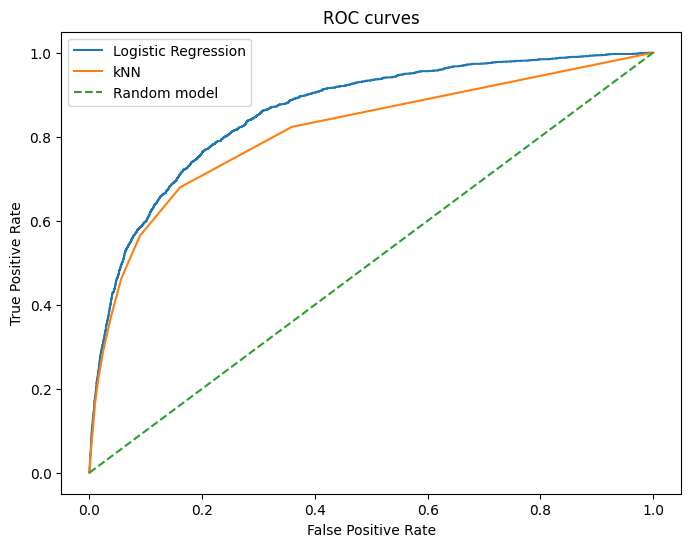

In [ ]:
from sklearn.metrics import roc_curve

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label="Logistic Regression")
plt.plot(fpr_knn, tpr_knn, label="kNN")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves")
plt.legend()
plt.show()

Далее рассмотрим матрицы ошибок для обеих моделей

Это поможет увидеть:
- сколько дефолтов модель правильно находит
- сколько дефолтов она пропускает
- сколько ложных срабатываний даёт

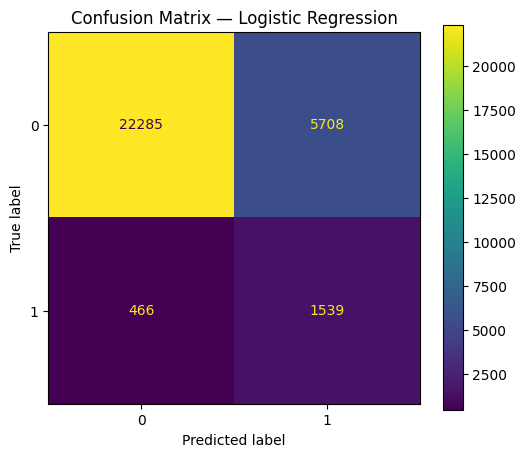

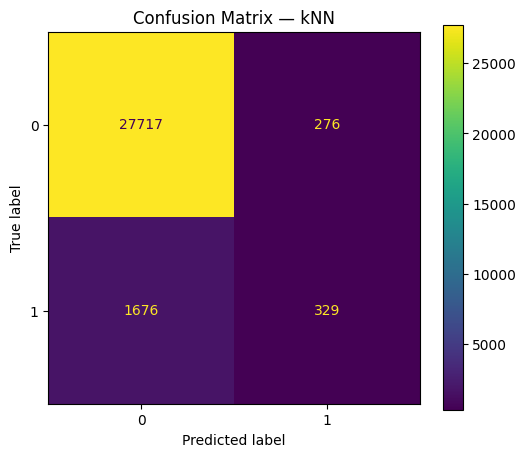

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg)
disp_logreg.plot(ax=ax)
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot(ax=ax)
plt.title("Confusion Matrix — kNN")
plt.show()

По матрицам ошибок видно, что логистическая регрессия обнаруживает больше реальных дефолтов, чем kNN, но при этом чаще даёт ложные срабатывания

Модель kNN, наоборот, осторожнее помечает заёмщиков как дефолтных, поэтому у неё меньше ложных тревог, но она пропускает значительную часть реальных дефолтов

Для данной задачи лучше ситуация, когда модель находит больше потенциально проблемных заёмщиков, даже ценой дополнительной проверки части из них

**Интерпретация логистической регрессии:**


In [ ]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": best_logreg.coef_[0]
})

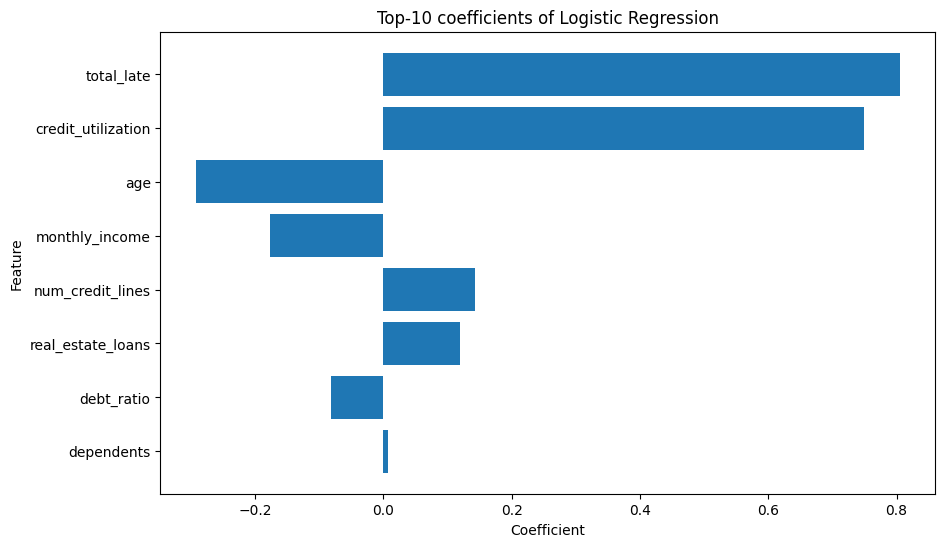

In [ ]:
coef_plot = coef_df.copy()
coef_plot["abs_coefficient"] = coef_plot["coefficient"].abs()
coef_plot = coef_plot.sort_values("abs_coefficient", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(coef_plot["feature"], coef_plot["coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top-10 coefficients of Logistic Regression")
plt.gca().invert_yaxis()
plt.show()

Наибольшие по модулю коэффициенты соответствуют признакам, которые сильнее всего влияют на вероятность дефолта

Это позволяет не только выбрать лучшую модель, но и понять, какие характеристики заёмщика сильнее всего связаны с риском просрочки

С практической точки зрения это важно, так как кредитный скоринг используется не только для предсказания, но и для интерпретации факторов риска

### Связь между количеством просрочек и риском дефолта

Дополнительно посмотрим, как распределяется предсказанная вероятность дефолта в зависимости от агрегированного признака `total_late`

Это позволяет проверить, соответствует ли поведение модели содержательному смыслу задачи: ожидается, что при большем числе просрочек риск дефолта должен возрастать

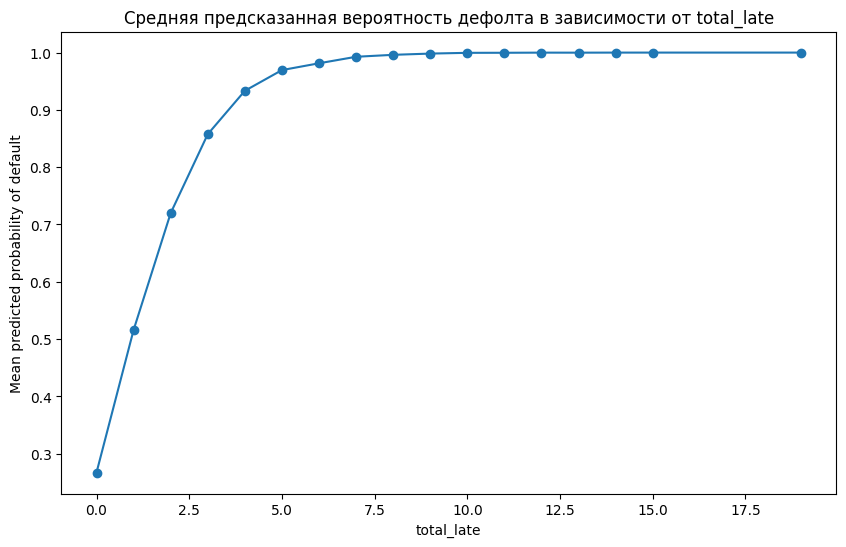

In [ ]:
test_analysis = X_test.copy()
test_analysis["default"] = y_test.values
test_analysis["predicted_proba_logreg"] = y_proba_logreg

grouped_late = test_analysis.groupby("total_late")["predicted_proba_logreg"].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(grouped_late["total_late"], grouped_late["predicted_proba_logreg"], marker="o")
plt.xlabel("total_late")
plt.ylabel("Mean predicted probability of default")
plt.title("Средняя предсказанная вероятность дефолта в зависимости от total_late")
plt.show()

## Итоговый вывод по моделям

В ходе проекта были обучены и сравнены две модели: логистическая регрессия и kNN

Логистическая регрессия показала:
- более высокое значение ROC-AUC
- значительно более высокий Recall
- лучшую способность выявлять заёмщиков с высоким риском дефолта

Модель kNN показала более высокий Precision и Accuracy, однако в условиях сильного дисбаланса классов это не является решающим преимуществом, так как она пропускает значительную часть реальных дефолтов

Таким образом, наиболее подходящей из рассмотренных моделей является логистическая регрессия